In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.applications import ResNet50, Xception, EfficientNetV2S, VGG16
from tensorflow.keras.layers import Dense, Flatten
from sklearn.metrics import classification_report
import warnings
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score, matthews_corrcoef, cohen_kappa_score
)
import seaborn as sns
warnings.filterwarnings("ignore")

## Load dataset
dataset contains pf header info

This dataset contains headers of 6978 binary executable 

In [4]:
df = pd.read_csv('Rpe_headers.csv')

In [5]:
# preview data
df.head()

,GR,0,1,2,3,4,5,6,7,8,...,1014,1015,1016,1017,1018,1019,1020,1021,1022,1023
0,0,77,90,144,0,3,0,0,0,4,...,0,0,0,0,0,0,0,0,0,0
1,0,77,90,144,0,3,0,0,0,4,...,0,0,0,0,0,0,0,0,0,0
2,0,77,90,144,0,3,0,0,0,4,...,0,0,0,0,0,0,0,0,0,0
3,0,77,90,144,0,3,0,0,0,4,...,0,0,0,0,0,0,0,0,0,0
4,0,77,90,144,0,3,0,0,0,4,...,0,0,0,0,0,0,0,0,0,0


In [6]:
# PE Header 1024
df.iloc[:, 1:]

,0,1,2,3,4,5,6,7,8,9,...,1014,1015,1016,1017,1018,1019,1020,1021,1022,1023
0,77,90,144,0,3,0,0,0,4,0,...,0,0,0,0,0,0,0,0,0,0
1,77,90,144,0,3,0,0,0,4,0,...,0,0,0,0,0,0,0,0,0,0
2,77,90,144,0,3,0,0,0,4,0,...,0,0,0,0,0,0,0,0,0,0
3,77,90,144,0,3,0,0,0,4,0,...,0,0,0,0,0,0,0,0,0,0
4,77,90,144,0,3,0,0,0,4,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6973,77,90,144,0,3,0,0,0,4,0,...,0,0,0,0,0,0,0,0,0,0
6974,77,90,144,0,3,0,0,0,4,0,...,0,0,0,0,0,0,0,0,0,0
6975,77,90,144,0,3,0,0,0,4,0,...,141,125,180,86,141,117,212,219,64,106
6976,77,90,144,0,3,0,0,0,4,0,...,0,0,0,0,0,0,0,0,0,0


In [7]:
df.sample(9,random_state=42)

,GR,0,1,2,3,4,5,6,7,8,...,1014,1015,1016,1017,1018,1019,1020,1021,1022,1023
2995,0,77,90,144,0,3,0,0,0,4,...,0,0,0,0,0,0,0,0,0,0
5246,1,77,90,144,0,3,0,0,0,4,...,0,0,0,0,0,0,0,0,0,0
3887,1,77,90,144,0,3,0,0,0,4,...,0,0,0,0,0,0,0,0,0,0
5948,1,77,90,144,0,3,0,0,0,4,...,236,93,195,144,144,144,144,144,144,144
469,0,77,90,144,0,3,0,0,0,4,...,0,0,0,0,0,0,0,0,0,0
538,0,77,90,144,0,3,0,0,0,4,...,0,0,0,0,0,0,0,0,0,0
6631,1,77,90,144,0,3,0,0,0,4,...,208,137,69,136,85,252,7,193,224,2
4482,1,77,90,144,0,3,0,0,0,4,...,0,0,0,0,0,0,0,0,0,0
1047,0,77,90,144,0,3,0,0,0,4,...,0,0,0,0,0,0,0,0,0,0


### Plot sample images

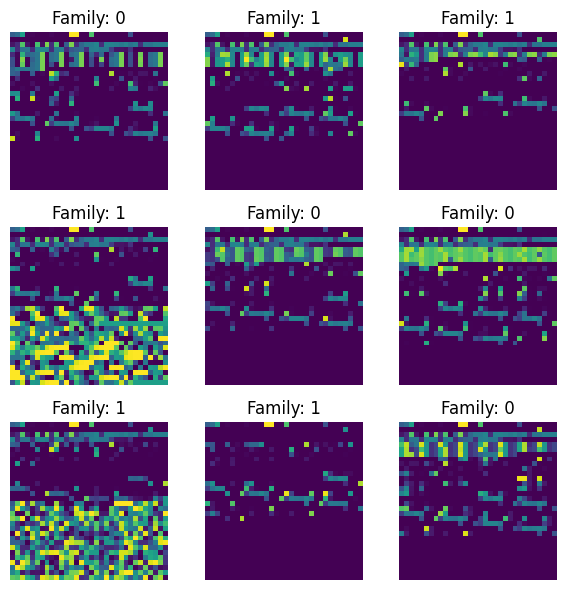

In [8]:
samp  = df.sample(9,random_state=42)
# Convert the numerical columns to color images
samp_images = samp.iloc[:, 1:].values.reshape(-1, 32, 32,1)
# Normalize the image values to [0, 1]
samp_images = samp_images / 255.0

# Create a new figure and plot the images
fig, axes = plt.subplots(3, 3, figsize=(6, 6))

# Flatten the axes array to make it easier to iterate over
axes = axes.flatten()

# Iterate over each image and plot it
for i in range(len(axes)):
    ax = axes[i]
    ax.imshow(samp_images[i], cmap='viridis')  # Assuming grayscale images
    ax.axis('off')  # Turn off axis labels
    ax.set_title(f'Family: {samp.iloc[i, 0]}')

plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()

## Convert to colored and Split data

In [30]:
# Split the data into training and validation sets (80% for training, 20% for validation)
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)
val_df, test_df = train_test_split(val_df, test_size=0.33, random_state=42)

# Convert the numerical columns to image
train_images = train_df.iloc[:, 1:].values.reshape(-1, 32, 32,1)
val_images = val_df.iloc[:, 1:].values.reshape(-1, 32, 32,1)
test_images = test_df.iloc[:, 1:].values.reshape(-1, 32, 32,1)

# Normalize the image values to [0, 1]
train_images = train_images / 255.0
val_images = val_images / 255.0
test_images = test_images / 255.0

# Convert the numerical columns to color images
train_images = np.repeat(train_images, 3, axis=3)
val_images = np.repeat(val_images, 3, axis=3)
test_images = np.repeat(test_images, 3, axis=3)

In [31]:
# Reshape each image in train_images to (256, 256, 3)
train_images = tf.image.resize(train_images, (256, 256))

# Reshape each image in val_images to (256, 256, 3)
val_images = tf.image.resize(val_images, (256, 256))

# Reshape each image in test_images to (256, 256, 3)
test_images = tf.image.resize(test_images, (256, 256))

## Build Resnet model for Goodware and randsomeware detection

In [32]:
# get target label
train_labels = train_df['GR'].values
val_labels = val_df['GR'].values
test_labels = test_df['GR'].values

In [33]:
# Define the ResNet model
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(256, 256, 3))

# Flatten the output from the base model
x = Flatten()(base_model.output)

# Add a dense layer with 26 units for classification
x = Dense(128, activation='relu')(x)
x = Dense(64, activation='relu')(x)
x = Dense(1, activation='sigmoid')(x) #Dense(2, activation='softmax')(x)

# Define the model
model = tf.keras.Model(inputs=base_model.input, outputs=x)

# Freeze some layers
for layer in base_model.layers:
    layer.trainable = False

In [34]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [35]:
model.fit(train_images, train_labels, epochs=20, validation_data=(val_images, val_labels))

Epoch 1/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 536s 3s/step - accuracy: 0.6324 - loss: 2.0440 - val_accuracy: 0.6930 - val_loss: 0.5907
Epoch 2/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 561s 3s/step - accuracy: 0.7547 - loss: 0.5180 - val_accuracy: 0.7807 - val_loss: 0.4764
Epoch 3/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 561s 3s/step - accuracy: 0.8208 - loss: 0.3973 - val_accuracy: 0.8545 - val_loss: 0.3640
Epoch 4/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 558s 3s/step - accuracy: 0.8098 - loss: 0.4082 - val_accuracy: 0.7936 - val_loss: 0.4412
Epoch 5/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 562s 3s/step - accuracy: 0.7988 - loss: 0.4614 - val_accuracy: 0.8813 - val_loss: 0.3229
Epoch 6/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 552s 3s/step - accuracy: 0.8180 - loss: 0.3991 - val_accuracy: 0.7893 - val_loss: 0.4409
Epoch 7/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 556s 3s/step - accuracy: 0.8295 - loss: 0.3881 - val_accuracy: 0.8663 - val_loss: 0.3237
Epoch 8/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 558s 3s/step - accuracy: 0.8310 - loss: 0.3657 - val_accu

In [36]:
# Evaluate the model on the validation set
y_pred = model.predict(test_images)

15/15 ━━━━━━━━━━━━━━━━━━━━ 45s 3s/step


In [37]:
# Convert the predictions to labels (0 or 1)
y_pred_labels = (y_pred > 0.5).astype(int)

# Get the true labels
y_true = test_labels

# Print the classification report
print(classification_report(y_true, y_pred_labels,target_names=['Goodware','Ransomeware']))

              precision    recall  f1-score   support

    Goodware       0.90      0.77      0.83       221
 Ransomeware       0.81      0.92      0.86       240

    accuracy                           0.85       461
   macro avg       0.86      0.85      0.85       461
weighted avg       0.85      0.85      0.85       461



In [38]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred_labels)
tn, fp, fn, tp = cm.ravel()

# Precision
precision = precision_score(y_true, y_pred_labels)

# Recall
recall = recall_score(y_true, y_pred_labels)

# Accuracy
accuracy = accuracy_score(y_true, y_pred_labels)

# FN rate (False Negative Rate)
fn_rate = fn / (fn + tp)

# FP rate (False Positive Rate)
fp_rate = fp / (fp + tn)

# F-measure
f_measure = f1_score(y_true, y_pred_labels)

# Error rate
error_rate = 1 - accuracy

# Matthews Correlation Coefficient (MCC)
mcc = matthews_corrcoef(y_true, y_pred_labels)

# Kappa
kappa = cohen_kappa_score(y_true, y_pred_labels)

# AUC-ROC
auc_roc = roc_auc_score(y_true, y_pred)

# Print the classification report
print(classification_report(y_true, y_pred_labels, target_names=['Goodware', 'Ransomeware']))

# Print all the metrics
print(f"Confusion Matrix: \n{cm}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"FN Rate: {fn_rate:.4f}")
print(f"FP Rate: {fp_rate:.4f}")
print(f"F-measure: {f_measure:.4f}")
print(f"Error Rate: {error_rate:.4f}")
print(f"MCC: {mcc:.4f}")
print(f"Kappa: {kappa:.4f}")
print(f"AUC-ROC: {auc_roc:.4f}")

              precision    recall  f1-score   support

    Goodware       0.90      0.77      0.83       221
 Ransomeware       0.81      0.92      0.86       240

    accuracy                           0.85       461
   macro avg       0.86      0.85      0.85       461
weighted avg       0.85      0.85      0.85       461

Confusion Matrix: 
[[171  50]
 [ 20 220]]
Precision: 0.8148
Recall: 0.9167
Accuracy: 0.8482
FN Rate: 0.0833
FP Rate: 0.2262
F-measure: 0.8627
Error Rate: 0.1518
MCC: 0.7002
Kappa: 0.6942
AUC-ROC: 0.9430


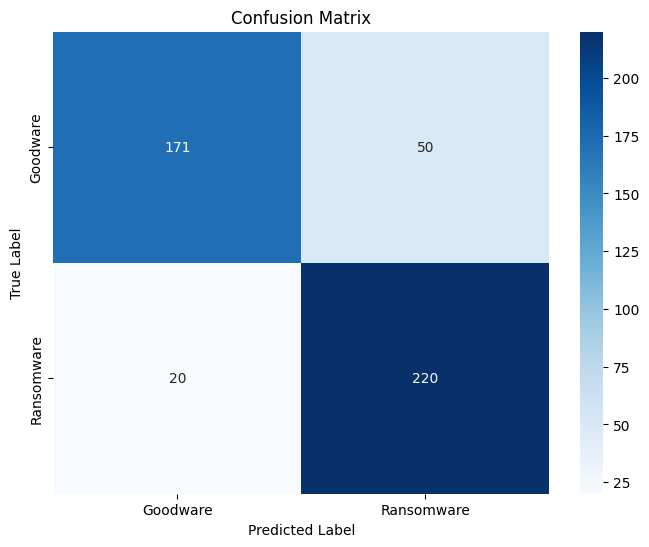

In [39]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Goodware', 'Ransomware'], yticklabels=['Goodware', 'Ransomware'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [40]:
lines = classification_report(y_true, y_pred_labels).split('\n')
recall_scores = [float(line.split()[2]) for line in lines[2:4]]

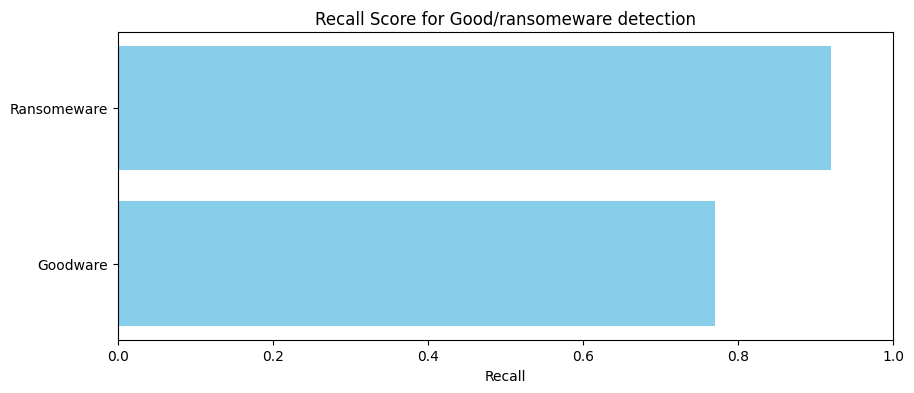

In [41]:
plt.figure(figsize=(10, 4))
plt.barh(['Goodware','Ransomeware'], recall_scores, color='skyblue')
plt.xlabel('Recall')
plt.title('Recall Score for Good/ransomeware detection')
plt.xlim(0, 1)  # Set x-axis limit to ensure consistency
plt.show()

## Build VGG16 model for Goodware/Ransomeware detection

In [42]:
# get target label
train_labels = train_df['GR'].values
val_labels = val_df['GR'].values
test_labels = test_df['GR'].values

In [43]:
# Define the ResNet model
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(256, 256, 3))

# Flatten the output from the base model
x = Flatten()(base_model.output)

# Add a dense layer with 26 units for classification
x = Dense(128, activation='relu')(x)
x = Dense(64, activation='relu')(x)
x = Dense(1, activation='sigmoid')(x) #Dense(2, activation='softmax')(x)

# Define the model
model_VGG = tf.keras.Model(inputs=base_model.input, outputs=x)

# Freeze some layers
for layer in base_model.layers:
    layer.trainable = False

In [44]:
# Compile the model
model_VGG.compile(optimizer='Adam', loss='binary_crossentropy', metrics=['accuracy'])

In [45]:
# train model
model_VGG.fit(train_images, train_labels, epochs=20, validation_data=(val_images, val_labels))

Epoch 1/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 1358s 8s/step - accuracy: 0.7743 - loss: 0.5459 - val_accuracy: 0.9102 - val_loss: 0.2482
Epoch 2/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 1421s 8s/step - accuracy: 0.9027 - loss: 0.2411 - val_accuracy: 0.9262 - val_loss: 0.1982
Epoch 3/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 1289s 7s/step - accuracy: 0.9309 - loss: 0.1763 - val_accuracy: 0.9401 - val_loss: 0.1767
Epoch 4/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 1289s 7s/step - accuracy: 0.9463 - loss: 0.1429 - val_accuracy: 0.9358 - val_loss: 0.1749
Epoch 5/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 1282s 7s/step - accuracy: 0.9448 - loss: 0.1445 - val_accuracy: 0.9369 - val_loss: 0.1728
Epoch 6/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 1289s 7s/step - accuracy: 0.9661 - loss: 0.0962 - val_accuracy: 0.9134 - val_loss: 0.2411
Epoch 7/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 1281s 7s/step - accuracy: 0.9420 - loss: 0.1399 - val_accuracy: 0.9305 - val_loss: 0.1947
Epoch 8/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 1293s 7s/step - accuracy: 0.9697 - loss: 0.0843 - 

In [46]:
# Evaluate the model on the validation set
y_pred = model_VGG.predict(test_images)

15/15 ━━━━━━━━━━━━━━━━━━━━ 86s 6s/step


In [47]:
# Convert the predictions to labels (0 or 1)
y_pred_labels = (y_pred > 0.5).astype(int)

# Get the true labels
y_true = test_labels

# Print the classification report
print(classification_report(y_true, y_pred_labels,target_names=['Goodware','Ransomeware']))

              precision    recall  f1-score   support

    Goodware       0.93      0.89      0.91       221
 Ransomeware       0.90      0.94      0.92       240

    accuracy                           0.92       461
   macro avg       0.92      0.91      0.92       461
weighted avg       0.92      0.92      0.92       461



In [48]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred_labels)
tn, fp, fn, tp = cm.ravel()

# Precision
precision = precision_score(y_true, y_pred_labels)

# Recall
recall = recall_score(y_true, y_pred_labels)

# Accuracy
accuracy = accuracy_score(y_true, y_pred_labels)

# FN rate (False Negative Rate)
fn_rate = fn / (fn + tp)

# FP rate (False Positive Rate)
fp_rate = fp / (fp + tn)

# F-measure
f_measure = f1_score(y_true, y_pred_labels)

# Error rate
error_rate = 1 - accuracy

# Matthews Correlation Coefficient (MCC)
mcc = matthews_corrcoef(y_true, y_pred_labels)

# Kappa
kappa = cohen_kappa_score(y_true, y_pred_labels)

# AUC-ROC
auc_roc = roc_auc_score(y_true, y_pred)

# Print the classification report
print(classification_report(y_true, y_pred_labels, target_names=['Goodware', 'Ransomeware']))

# Print all the metrics
print(f"Confusion Matrix: \n{cm}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"FN Rate: {fn_rate:.4f}")
print(f"FP Rate: {fp_rate:.4f}")
print(f"F-measure: {f_measure:.4f}")
print(f"Error Rate: {error_rate:.4f}")
print(f"MCC: {mcc:.4f}")
print(f"Kappa: {kappa:.4f}")
print(f"AUC-ROC: {auc_roc:.4f}")

              precision    recall  f1-score   support

    Goodware       0.93      0.89      0.91       221
 Ransomeware       0.90      0.94      0.92       240

    accuracy                           0.92       461
   macro avg       0.92      0.91      0.92       461
weighted avg       0.92      0.92      0.92       461

Confusion Matrix: 
[[196  25]
 [ 14 226]]
Precision: 0.9004
Recall: 0.9417
Accuracy: 0.9154
FN Rate: 0.0583
FP Rate: 0.1131
F-measure: 0.9206
Error Rate: 0.0846
MCC: 0.8311
Kappa: 0.8302
AUC-ROC: 0.9802


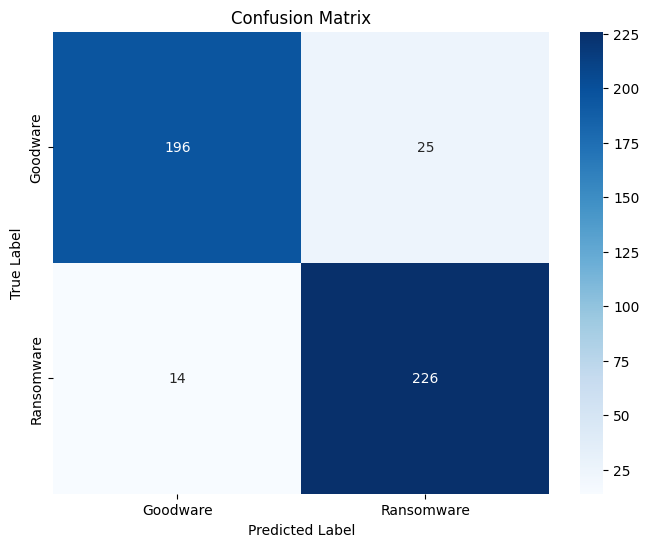

In [49]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Goodware', 'Ransomware'], yticklabels=['Goodware', 'Ransomware'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

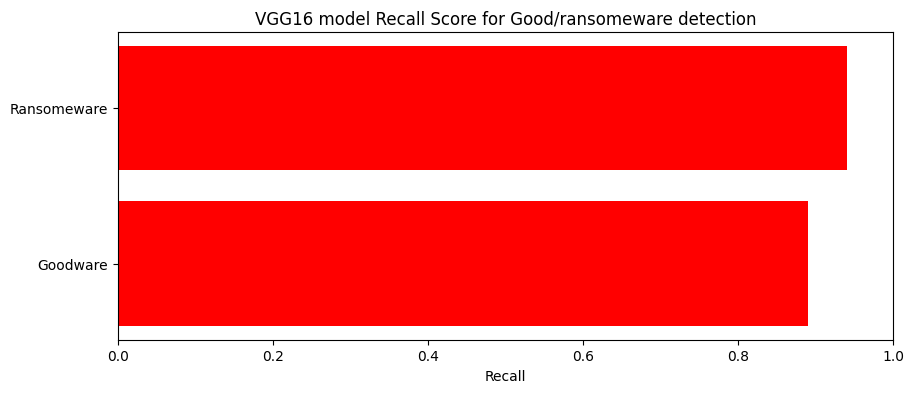

In [50]:
lines = classification_report(y_true, y_pred_labels).split('\n')
recall_scores = [float(line.split()[2]) for line in lines[2:4]]

plt.figure(figsize=(10, 4))
plt.barh(['Goodware','Ransomeware'], recall_scores, color='red')
plt.xlabel('Recall')
plt.title('VGG16 model Recall Score for Good/ransomeware detection')
plt.xlim(0, 1)  # Set x-axis limit to ensure consistency
plt.show()

## Build Xception model for Goodware/Ransomeware detection

In [51]:
# get target label
train_labels = train_df['GR'].values
val_labels = val_df['GR'].values
test_labels = test_df['GR'].values

In [52]:
# Define the ResNet model
base_model = Xception(weights='imagenet', include_top=False, input_shape=(256, 256, 3))

# Flatten the output from the base model
x = Flatten()(base_model.output)

# Add a dense layer with 26 units for classification
x = Dense(256, activation='relu')(x)
x = Dense(128, activation='relu')(x)
x = Dense(64, activation='relu')(x)
x = Dense(1, activation='sigmoid')(x) #Dense(2, activation='softmax')(x)

# Define the model
model_xception = tf.keras.Model(inputs=base_model.input, outputs=x)

# Freeze some layers
for layer in base_model.layers:
    layer.trainable = False

In [53]:
# Compile the model
model_xception.compile(optimizer='Adam', loss='binary_crossentropy', metrics=['accuracy'])

In [54]:
# train model
model_xception.fit(train_images, train_labels, epochs=15, validation_data=(val_images, val_labels))

Epoch 1/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 682s 4s/step - accuracy: 0.7438 - loss: 1.3139 - val_accuracy: 0.8802 - val_loss: 0.2790
Epoch 2/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 709s 4s/step - accuracy: 0.8847 - loss: 0.2818 - val_accuracy: 0.8963 - val_loss: 0.3029
Epoch 3/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 667s 4s/step - accuracy: 0.9216 - loss: 0.1973 - val_accuracy: 0.9187 - val_loss: 0.2491
Epoch 4/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 651s 4s/step - accuracy: 0.9401 - loss: 0.1610 - val_accuracy: 0.8642 - val_loss: 0.4711
Epoch 5/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 661s 4s/step - accuracy: 0.9426 - loss: 0.1537 - val_accuracy: 0.9294 - val_loss: 0.2222
Epoch 6/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 703s 4s/step - accuracy: 0.9500 - loss: 0.1391 - val_accuracy: 0.9283 - val_loss: 0.2123
Epoch 7/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 697s 4s/step - accuracy: 0.9586 - loss: 0.0966 - val_accuracy: 0.9326 - val_loss: 0.1728
Epoch 8/15
175/175 ━━━━━━━━━━━━━━━━━━━━ 676s 4s/step - accuracy: 0.9644 - loss: 0.0898 - val_accu

In [55]:
# Evaluate the model on the validation set
y_pred = model_xception.predict(test_images)

15/15 ━━━━━━━━━━━━━━━━━━━━ 53s 3s/step


In [56]:
# Convert the predictions to labels (0 or 1)
y_pred_labels = (y_pred > 0.5).astype(int)

# Get the true labels
y_true = test_labels

# Print the classification report
print(classification_report(y_true, y_pred_labels,target_names=['Goodware','Ransomeware']))

              precision    recall  f1-score   support

    Goodware       0.88      0.96      0.92       221
 Ransomeware       0.96      0.88      0.92       240

    accuracy                           0.92       461
   macro avg       0.92      0.92      0.92       461
weighted avg       0.92      0.92      0.92       461



In [57]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred_labels)
tn, fp, fn, tp = cm.ravel()

# Precision
precision = precision_score(y_true, y_pred_labels)

# Recall
recall = recall_score(y_true, y_pred_labels)

# Accuracy
accuracy = accuracy_score(y_true, y_pred_labels)

# FN rate (False Negative Rate)
fn_rate = fn / (fn + tp)

# FP rate (False Positive Rate)
fp_rate = fp / (fp + tn)

# F-measure
f_measure = f1_score(y_true, y_pred_labels)

# Error rate
error_rate = 1 - accuracy

# Matthews Correlation Coefficient (MCC)
mcc = matthews_corrcoef(y_true, y_pred_labels)

# Kappa
kappa = cohen_kappa_score(y_true, y_pred_labels)

# AUC-ROC
auc_roc = roc_auc_score(y_true, y_pred)

# Print the classification report
print(classification_report(y_true, y_pred_labels, target_names=['Goodware', 'Ransomeware']))

# Print all the metrics
print(f"Confusion Matrix: \n{cm}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"FN Rate: {fn_rate:.4f}")
print(f"FP Rate: {fp_rate:.4f}")
print(f"F-measure: {f_measure:.4f}")
print(f"Error Rate: {error_rate:.4f}")
print(f"MCC: {mcc:.4f}")
print(f"Kappa: {kappa:.4f}")
print(f"AUC-ROC: {auc_roc:.4f}")

              precision    recall  f1-score   support

    Goodware       0.88      0.96      0.92       221
 Ransomeware       0.96      0.88      0.92       240

    accuracy                           0.92       461
   macro avg       0.92      0.92      0.92       461
weighted avg       0.92      0.92      0.92       461

Confusion Matrix: 
[[213   8]
 [ 30 210]]
Precision: 0.9633
Recall: 0.8750
Accuracy: 0.9176
FN Rate: 0.1250
FP Rate: 0.0362
F-measure: 0.9170
Error Rate: 0.0824
MCC: 0.8393
Kappa: 0.8355
AUC-ROC: 0.9712


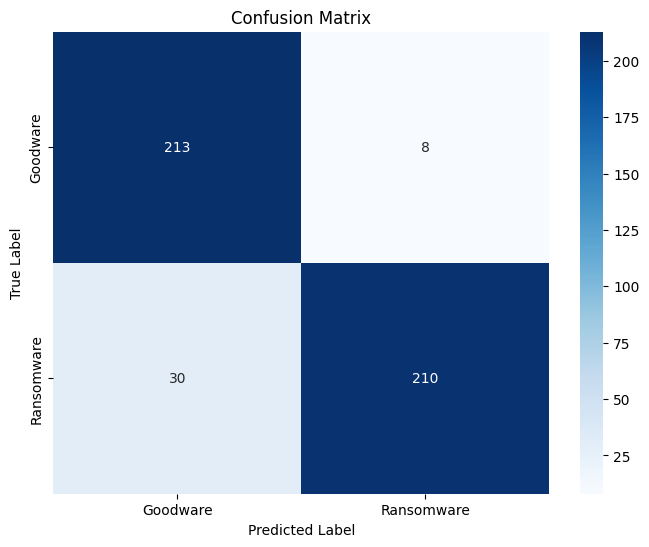

In [58]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Goodware', 'Ransomware'], yticklabels=['Goodware', 'Ransomware'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

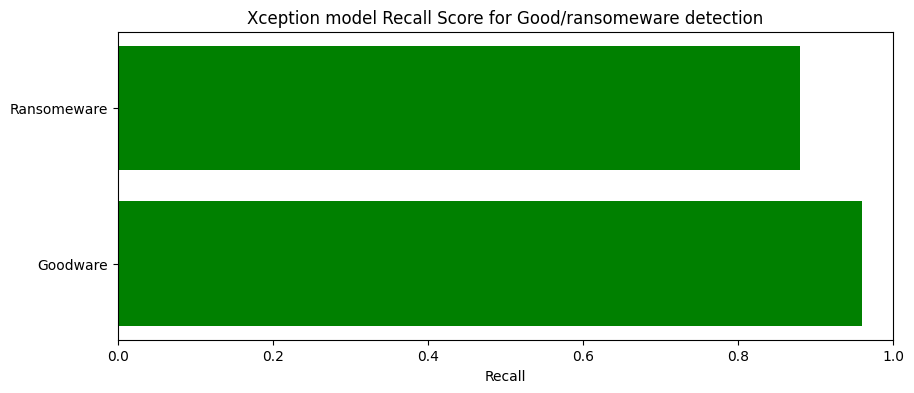

In [59]:
lines = classification_report(y_true, y_pred_labels).split('\n')
recall_scores = [float(line.split()[2]) for line in lines[2:4]]

plt.figure(figsize=(10, 4))
plt.barh(['Goodware','Ransomeware'], recall_scores, color='green')
plt.xlabel('Recall')
plt.title('Xception model Recall Score for Good/ransomeware detection')
plt.xlim(0, 1)  # Set x-axis limit to ensure consistency
plt.show()